---
title: "Change of variables from scratch"
short_title: "00 · Change of variables"
subtitle: "The one formula the whole curriculum is built on — 1D, 2D, d-D, both directions"
description: >
  Derive the change-of-variables / log-determinant formula from first
  principles in JAX. Verify it numerically in 1D against an analytic
  density, in 2D against a linear map, and in d-D against an
  autodiff Jacobian. Then watch a gauss_flows bijector report exactly
  the log-determinant we computed by hand.
---

(sec-nb-00)=
# 00 — Change of variables from scratch

Every Gaussianization method in this curriculum — RBIG, coupling flows,
FFJORD, spline flows — is a way of **building an invertible map** $T$ that
turns messy data into a standard Gaussian. The single fact that makes any of
this useful for *density estimation* is the **change-of-variables formula**
{cite}`rezende2015nf,papamakarios2021nf`: it tells us how a probability density
transforms when we push it through $T$.
Get this one formula and its $\log\det$ bookkeeping right and the rest of the
course is engineering.

**What you will see**

- The 1D formula $p_X(x) = p_Z(T(x))\,|T'(x)|$ derived and checked against an
  analytic density.
- The $d$-D generalisation $p_X(x) = p_Z(T(x))\,|\det J_T(x)|$, checked in 2D
  against a hand-computed determinant and in 5D against an autodiff Jacobian.
- Why we *always* work in log-space: $\log p_X(x) = \log p_Z(T(x)) +
  \log|\det J_T(x)|$.
- A `gauss_flows` bijector reporting the *same* $\log|\det J|$ our generic
  autodiff computation produces — the bridge from the math to the library.

:::{note} This is a *foundations* notebook
We deliberately implement the maps by hand and lean on the packages only to
*confirm* the arithmetic. Later notebooks (Parts 1–9) stop re-deriving and
just call [`rbig`](https://github.com/jejjohnson/rbig) and
[`gauss_flows`](https://github.com/jejjohnson/gauss_flows).
:::

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)  # log-dets deserve float64
rng = np.random.default_rng(0)

## 1. The 1D formula

Let $X$ be a continuous random variable with density $p_X$, and let
$T:\mathbb{R}\to\mathbb{R}$ be a smooth, strictly monotone (hence invertible)
map. Define $Z = T(X)$. Conservation of probability mass over an
infinitesimal interval says $p_X(x)\,|dx| = p_Z(z)\,|dz|$, and since
$dz = T'(x)\,dx$,

$$
p_Z(z) = \frac{p_X(x)}{|T'(x)|}\Bigg|_{x = T^{-1}(z)},
\qquad\text{equivalently}\qquad
p_X(x) = p_Z\big(T(x)\big)\,\big|T'(x)\big|.
$$

The $|T'(x)|$ factor is the 1D Jacobian: it is the local stretch/squeeze of
the line under $T$, and it is exactly what keeps the transformed density
normalised.

**Worked example.** Take $X \sim \text{LogNormal}$, i.e. $X = e^W$ with
$W \sim \mathcal{N}(0,1)$, and the map $T(x) = \log x$. Then $Z = T(X) = W$ is
standard normal *by construction*, so we know the answer and can check the
formula. Here $T'(x) = 1/x$, so the formula predicts
$p_Z(z) = p_X(e^z)\cdot e^z$.

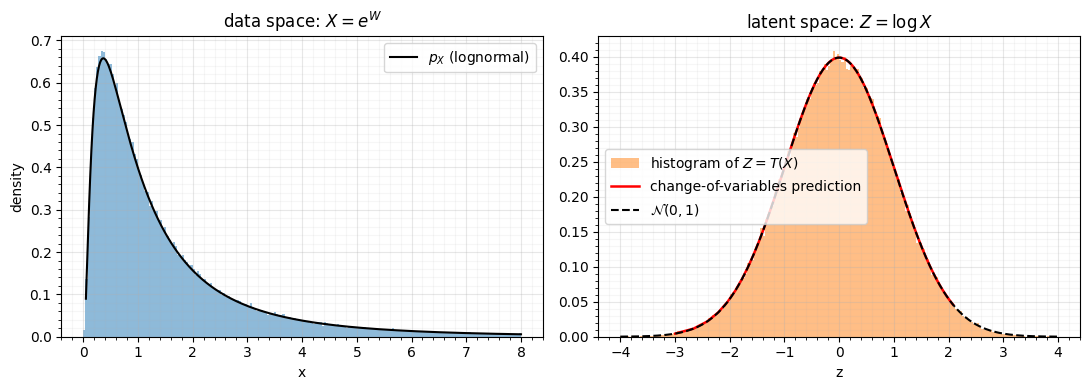

In [2]:
# Sample X = exp(W), W ~ N(0,1).
W = rng.standard_normal(200_000)
X = np.exp(W)

# The map and its derivative (let JAX differentiate it so we never hand-code T').
T = jnp.log
dT = jax.vmap(jax.grad(T))  # T'(x) = 1/x

x_grid = jnp.linspace(0.05, 8.0, 400)
p_X = stats.lognorm.pdf(np.asarray(x_grid), s=1.0)  # true p_X
# Change of variables: p_Z(z) at z = T(x) equals p_X(x) / |T'(x)|.
z_at = np.asarray(T(x_grid))
p_Z_pred = p_X / np.abs(np.asarray(dT(x_grid)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X, bins=200, density=True, range=(0, 8), color="tab:blue", alpha=0.5)
axes[0].plot(x_grid, p_X, "k-", lw=1.5, label=r"$p_X$ (lognormal)")
axes[0].set(title=r"data space: $X = e^W$", xlabel="x", ylabel="density")
axes[0].legend(); style_ax(axes[0])

zz = np.linspace(-4, 4, 400)
axes[1].hist(np.asarray(T(X)), bins=200, density=True, range=(-4, 4),
             color="tab:orange", alpha=0.5, label="histogram of $Z=T(X)$")
axes[1].plot(z_at, p_Z_pred, "r-", lw=1.8, label=r"change-of-variables prediction")
axes[1].plot(zz, stats.norm.pdf(zz), **GAUSS_KW, label=r"$\mathcal{N}(0,1)$")
axes[1].set(title=r"latent space: $Z = \log X$", xlabel="z")
axes[1].legend(); style_ax(axes[1])
fig.tight_layout()

The red change-of-variables prediction lands exactly on both the empirical
histogram of $Z$ and the analytic $\mathcal{N}(0,1)$ curve. The $|T'(x)|$
factor is doing real work: drop it and the prediction would integrate to
something other than 1.

## 2. The $d$-dimensional formula

In $d$ dimensions the scalar derivative $T'(x)$ becomes the **Jacobian
matrix** $J_T(x)$ with $[J_T]_{ij} = \partial T_i / \partial x_j$, and its
absolute determinant replaces $|T'(x)|$:

$$
p_X(x) = p_Z\big(T(x)\big)\,\big|\det J_T(x)\big|.
$$

$|\det J_T(x)|$ is the local volume change: the factor by which $T$ inflates
or shrinks a tiny box of probability mass around $x$.

**Linear case.** For an affine map $T(x) = A x + b$ the Jacobian is constant,
$J_T = A$, so $|\det J_T| = |\det A|$ everywhere. We can read the answer off
directly and check it.

In [3]:
A = jnp.array([[1.3, 0.7], [-0.4, 0.9]])
b = jnp.array([0.5, -1.0])
T_lin = lambda x: A @ x + b

x0 = jnp.array([0.3, -1.2])
J = jax.jacfwd(T_lin)(x0)  # autodiff Jacobian at x0
print("autodiff Jacobian J_T(x0):\n", np.asarray(J))
print(f"|det J| (autodiff)      = {abs(jnp.linalg.det(J)):.6f}")
print(f"|det A| (by hand)       = {abs(jnp.linalg.det(A)):.6f}")
print(f"log|det J| (autodiff)   = {jnp.linalg.slogdet(J)[1]:.6f}")

autodiff Jacobian J_T(x0):
 [[ 1.3  0.7]
 [-0.4  0.9]]
|det J| (autodiff)      = 1.450000
|det A| (by hand)       = 1.450000
log|det J| (autodiff)   = 0.371564


**Seeing $|\det J|$ as area change.** The determinant is not just a number to
plug in — it is the factor by which $T$ scales *area* locally. We can watch
this directly: lay a unit grid over the plane, push every cell through $T$,
and colour each warped cell by its Jacobian determinant. For the **linear**
map every cell scales by the *same* $|\det A| = 1.45$ (constant colour). For a
**nonlinear** map the determinant *varies with position* — which is exactly
why in general $|\det J_T(x)|$ is a function of $x$, evaluated afresh at every
point.

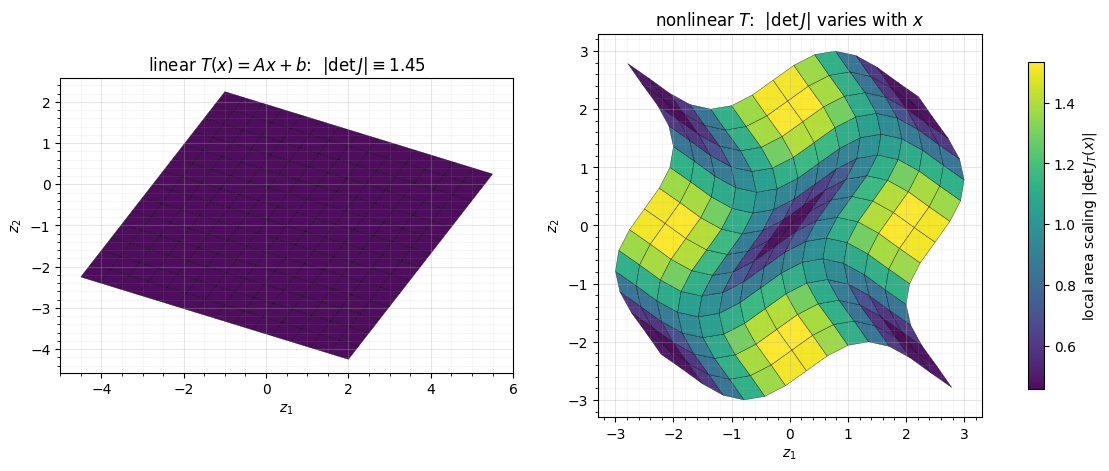

In [4]:
from matplotlib.collections import PolyCollection


# A nonlinear map whose Jacobian determinant varies across the plane.
def T_wave(x):
    return x + 0.5 * jnp.array([jnp.sin(1.5 * x[1]), jnp.sin(1.5 * x[0])])


def warp_grid(ax, fn, title, lo=-2.5, hi=2.5, n=14):
    """Push a unit grid through fn; colour each cell by its |det J| at the centre."""
    edges = np.linspace(lo, hi, n + 1)
    fn_v = jax.vmap(fn)

    def absdet(p):  # |det J_fn(p)| via autodiff Jacobian
        return jnp.exp(jnp.linalg.slogdet(jax.jacfwd(fn)(p))[1])
    polys, vals = [], []
    for i in range(n):
        for j in range(n):
            corners = jnp.array([
                [edges[i], edges[j]], [edges[i + 1], edges[j]],
                [edges[i + 1], edges[j + 1]], [edges[i], edges[j + 1]],
            ])
            polys.append(np.asarray(fn_v(corners)))
            center = jnp.array([(edges[i] + edges[i + 1]) / 2,
                                (edges[j] + edges[j + 1]) / 2])
            vals.append(float(absdet(center)))
    pc = PolyCollection(polys, array=np.array(vals), cmap="viridis",
                        edgecolors="k", linewidths=0.25, alpha=0.95)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set(title=title, xlabel="$z_1$", ylabel="$z_2$")
    style_ax(ax)
    return pc


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
warp_grid(axes[0], T_lin, r"linear $T(x)=Ax+b$:  $|\det J|\equiv 1.45$")
pc = warp_grid(axes[1], T_wave, r"nonlinear $T$:  $|\det J|$ varies with $x$")
fig.colorbar(pc, ax=axes, shrink=0.85, label=r"local area scaling $|\det J_T(x)|$")

Left: a unit grid becomes a lattice of identical parallelograms — the linear
map stretches area by the constant $|\det A| = 1.45$ everywhere (uniform
colour). Right: the same grid warps unevenly; cells in expanding regions are
larger and brighter, compressed regions smaller and darker. The
change-of-variables formula handles both cases identically because it reads
$|\det J_T(x)|$ off **locally**, at each $x$.

## 3. Always work in log-space

Densities span many orders of magnitude and $\det$ of a $d\times d$ matrix is
a product of $d$ numbers — both overflow/underflow fast. So in practice we
*never* form $|\det J|$ directly; we accumulate its logarithm:

$$
\boxed{\;\log p_X(x) = \log p_Z\big(T(x)\big) + \log\big|\det J_T(x)\big|\;}
$$

This is *the* equation a normalizing flow evaluates. `jax.numpy.linalg.slogdet`
returns $\log|\det|$ stably (with a separate sign), which is exactly what we
want. Let's verify the full log-density identity on a nonlinear map in 5D,
using an autodiff Jacobian so the check is completely generic.

In [5]:
d = 5
# A smooth invertible nonlinearity: elementwise tanh-shift composed with a
# fixed well-conditioned linear mixer. (Invertible because tanh is monotone and
# M is full rank — we only need it to be a local diffeomorphism for the check.)
M = jnp.asarray(rng.standard_normal((d, d)) * 0.3 + jnp.eye(d))


def T_nl(x):
    return M @ jnp.tanh(0.7 * x) + 0.5 * x


def logdet_autodiff(x):
    J = jax.jacfwd(T_nl)(x)
    return jnp.linalg.slogdet(J)[1]


# Base density p_Z = N(0, I); pull a point through and score it two ways.
x = jnp.asarray(rng.standard_normal(d))
z = T_nl(x)
log_pz = jax.scipy.stats.multivariate_normal.logpdf(z, jnp.zeros(d), jnp.eye(d))
log_px = log_pz + logdet_autodiff(x)
print(f"log p_Z(T(x))     = {log_pz:.6f}")
print(f"log|det J_T(x)|   = {logdet_autodiff(x):.6f}")
print(f"=> log p_X(x)     = {log_px:.6f}")

# Monte-Carlo sanity check: the pushforward of x ~ p_X through T must be N(0,I).
# Equivalently the average log p_X over true X-samples should match the
# entropy-style identity E[log p_X(X)] = E[log p_Z(Z)] (T is a bijection).
xs = jnp.asarray(rng.standard_normal((4000, d)))  # stand-in samples
batched = jax.vmap(lambda u: jax.scipy.stats.multivariate_normal.logpdf(
    T_nl(u), jnp.zeros(d), jnp.eye(d)) + logdet_autodiff(u))(xs)
print(f"\nbatched log p_X over 4000 points: finite={bool(jnp.all(jnp.isfinite(batched)))}")

log p_Z(T(x))     = -7.987257
log|det J_T(x)|   = -0.126274
=> log p_X(x)     = -8.113531



batched log p_X over 4000 points: finite=True


## 4. The bridge: a `gauss_flows` bijector reports this exact number

Every bijector in [`gauss_flows`](https://github.com/jejjohnson/gauss_flows)
exposes `transform_and_log_det(x) -> (z, log|det J|)`. That second return
value *is* the $\log|\det J_T(x)|$ we have been computing — the library does
the bookkeeping analytically and cheaply (no $d\times d$ determinant), but it
must agree with a brute-force autodiff Jacobian. Let's confirm that on a
`MixtureGaussianCDF` marginal bijector, the workhorse of Gaussianization.

In [6]:
import gauss_flows as gf

bij = gf.MixtureGaussianCDF(n_components=8, shape=(d,))

xv = jnp.asarray(rng.standard_normal(d))
z_lib, logdet_lib = bij.transform_and_log_det(xv)

# Brute-force: differentiate the bijector's own transform and take slogdet.
J_lib = jax.jacfwd(bij.transform)(xv)
logdet_bruteforce = jnp.linalg.slogdet(J_lib)[1]

print(f"gauss_flows analytic log|det J| = {logdet_lib:.8f}")
print(f"autodiff-Jacobian  log|det J|   = {logdet_bruteforce:.8f}")
print(f"absolute difference             = {abs(logdet_lib - logdet_bruteforce):.2e}")
assert jnp.allclose(logdet_lib, logdet_bruteforce, atol=1e-6)
print("\n[ok] the library's log-det is the change-of-variables Jacobian.")

gauss_flows analytic log|det J| = 1.79662669
autodiff-Jacobian  log|det J|   = 1.79662669
absolute difference             = 2.89e-15

[ok] the library's log-det is the change-of-variables Jacobian.


The two agree to floating-point precision. That is the whole point of this
notebook: the abstract formula from §1–§3 is *literally* what the package
returns, so once you trust the formula you can trust the library — and stop
computing $d\times d$ determinants by hand, because the analytic log-det is
both exact and far cheaper.

## Recap

| concept | formula | in code |
|---|---|---|
| 1D change of variables | $p_X(x)=p_Z(T(x))\,\lvert T'(x)\rvert$ | `p_X / abs(jax.grad(T)(x))` |
| $d$-D change of variables | $p_X(x)=p_Z(T(x))\,\lvert\det J_T(x)\rvert$ | `slogdet(jax.jacfwd(T)(x))` |
| log-density (what flows evaluate) | $\log p_X = \log p_Z(T(x)) + \log\lvert\det J_T\rvert$ | `log_pz + log_det` |
| the library's job | analytic, cheap $\log\lvert\det J\rvert$ | `bij.transform_and_log_det(x)` |

**Next up.** A single bijector is rarely enough. In
[01 — Composition & the additive log-determinant](01_composition_logdet.ipynb)
we stack maps $T = T_K\circ\cdots\circ T_1$ and show the log-dets simply
**add** — the rule that lets us build deep flows.